#Daily challenge cnn mnist

In [3]:
# Daily Challenge : Classifying Handwritten Digits with CNNs
# Comparaison entre un réseau Dense et un réseau CNN sur le dataset MNIST

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

In [4]:
# ÉTAPE 1 : Chargement du dataset MNIST

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Formes des données brutes :")
print("x_train :", x_train.shape)  # (60000, 28, 28)
print("y_train :", y_train.shape)  # (60000,)
print("x_test  :", x_test.shape)   # (10000, 28, 28)
print("y_test  :", y_test.shape)   # (10000,)


Formes des données brutes :
x_train : (60000, 28, 28)
y_train : (60000,)
x_test  : (10000, 28, 28)
y_test  : (10000,)


In [5]:
# ÉTAPE 2 : Prétraitement pour le réseau Dense (Fully Connected)

# Aplatir les images 28x28 en vecteurs de 784 valeurs
x_train_dense = x_train.reshape(60000, 784)
x_test_dense  = x_test.reshape(10000, 784)

# Normaliser les pixels entre 0 et 1
x_train_dense = x_train_dense / 255.0
x_test_dense  = x_test_dense  / 255.0

# Convertir les labels en vecteurs one-hot (ex: 3 -> [0,0,0,1,0,0,0,0,0,0])
y_train_enc = to_categorical(y_train, 10)
y_test_enc  = to_categorical(y_test,  10)

print("\nFormes après prétraitement Dense :")
print("x_train_dense :", x_train_dense.shape)  # (60000, 784)
print("y_train_enc   :", y_train_enc.shape)     # (60000, 10)


Formes après prétraitement Dense :
x_train_dense : (60000, 784)
y_train_enc   : (60000, 10)


In [7]:
# ÉTAPE 3 : Construction et entraînement du réseau Dense

model_dense = keras.Sequential([
    # Couche d'entrée : 784 neurones (une image aplatie)
    layers.Dense(128, activation='relu', input_shape=(784,)),
    # Deuxième couche cachée
    layers.Dense(64, activation='relu'),
    # Couche de sortie : 10 neurones pour les 10 chiffres possibles
    layers.Dense(10, activation='softmax')
])

model_dense.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_dense.summary()


# Entraînement du modèle Dense
history_dense = model_dense.fit(
    x_train_dense, y_train_enc,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Évaluation du modèle Dense
loss_dense, acc_dense = model_dense.evaluate(
    x_test_dense, y_test_enc, verbose=0
)
print(f"\nRéseau Dense    -> Précision : {acc_dense*100:.2f}%")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9281 - loss: 0.2489 - val_accuracy: 0.9693 - val_loss: 0.1063
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9689 - loss: 0.1051 - val_accuracy: 0.9717 - val_loss: 0.0942
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9774 - loss: 0.0730 - val_accuracy: 0.9765 - val_loss: 0.0797
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9831 - loss: 0.0544 - val_accuracy: 0.9787 - val_loss: 0.0757
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9859 - loss: 0.0443 - val_accuracy: 0.9770 - val_loss: 0.0886
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9881 - loss: 0.0363 - val_accuracy: 0.9798 - val_loss: 0.0816
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9906 - loss: 0.0284 - val_accuracy: 0.9783 - val_loss: 0.0832
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9924 - loss: 0.0232 - 

In [9]:
 #ÉTAPE 4 : Prétraitement pour le réseau CNN

# Le CNN attend des images avec une dimension de canal : (batch, hauteur, largeur, canaux)
x_train_cnn = x_train.reshape(60000, 28, 28, 1) / 255.0
x_test_cnn  = x_test.reshape(10000, 28, 28, 1)  / 255.0

print("\nFormes après prétraitement CNN :")
print("x_train_cnn :", x_train_cnn.shape)  # (60000, 28, 28, 1)


Formes après prétraitement CNN :
x_train_cnn : (60000, 28, 28, 1)


In [10]:
# ÉTAPE 5 : Construction et entraînement du réseau CNN

model_cnn = keras.Sequential([
    # Première couche de convolution : 32 filtres de taille 3x3
    # La convolution détecte des patterns locaux comme les bords et les courbes
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),

    # MaxPooling réduit la taille spatiale de moitié pour diminuer les calculs
    layers.MaxPooling2D(2, 2),

    # Deuxième couche de convolution : 64 filtres pour détecter des patterns plus complexes
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Aplatir les feature maps en un vecteur 1D pour les couches Dense
    layers.Flatten(),

    # Couche Dense pour la classification finale
    layers.Dense(64, activation='relu'),

    # Couche de sortie : 10 classes
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

# Entraînement du modèle CNN
history_cnn = model_cnn.fit(
    x_train_cnn, y_train_enc,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Évaluation du modèle CNN
loss_cnn, acc_cnn = model_cnn.evaluate(
    x_test_cnn, y_test_enc, verbose=0
)
print(f"Réseau CNN      -> Précision : {acc_cnn*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9564 - loss: 0.1432 - val_accuracy: 0.9877 - val_loss: 0.0431
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9850 - loss: 0.0468 - val_accuracy: 0.9873 - val_loss: 0.0432
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9896 - loss: 0.0325 - val_accuracy: 0.9898 - val_loss: 0.0354
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9925 - loss: 0.0225 - val_accuracy: 0.9897 - val_loss: 0.0424
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9941 - loss: 0.0169 - val_accuracy: 0.9903 - val_loss: 0.0376
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9955 - loss: 0.0134 - val_accuracy: 0.9885 - val_loss: 0.0494
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9967 - loss: 0.0097 - val_accuracy: 0.9918 - val_loss: 0.0318
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9970 -

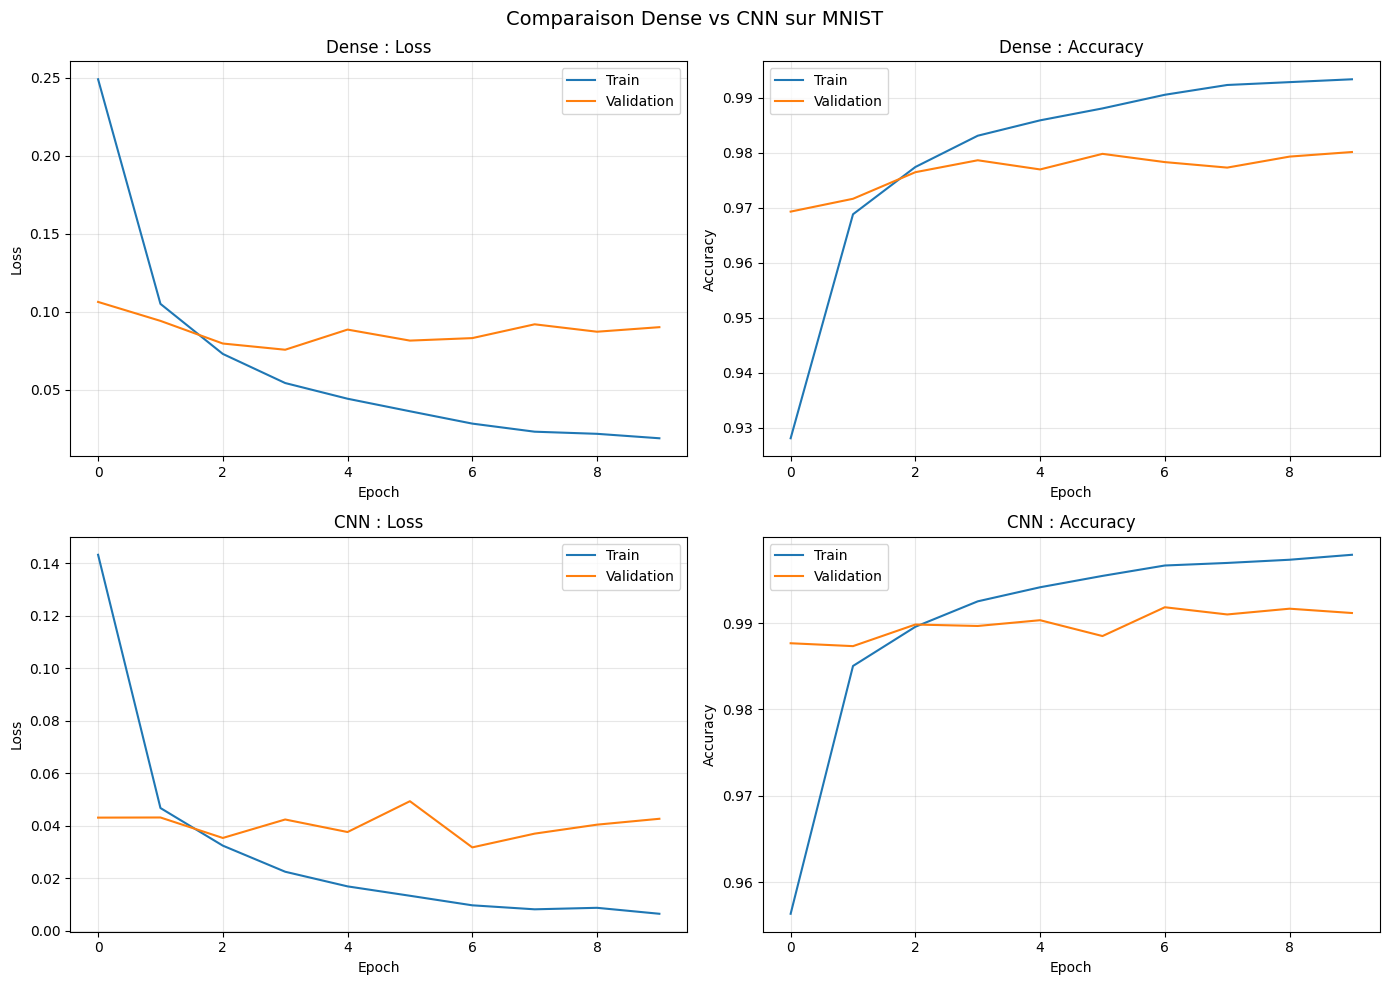


Résultats finaux sur le test set :
Réseau Dense    : 97.68%
Réseau CNN      : 99.23%
Gain du CNN     : +1.55%


In [11]:
# ÉTAPE 6 : Comparaison visuelle des deux modèles

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Courbe de loss du modèle Dense
axes[0, 0].plot(history_dense.history['loss'],     label='Train')
axes[0, 0].plot(history_dense.history['val_loss'], label='Validation')
axes[0, 0].set_title('Dense : Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Courbe d'accuracy du modèle Dense
axes[0, 1].plot(history_dense.history['accuracy'],     label='Train')
axes[0, 1].plot(history_dense.history['val_accuracy'], label='Validation')
axes[0, 1].set_title('Dense : Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Courbe de loss du modèle CNN
axes[1, 0].plot(history_cnn.history['loss'],     label='Train')
axes[1, 0].plot(history_cnn.history['val_loss'], label='Validation')
axes[1, 0].set_title('CNN : Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Courbe d'accuracy du modèle CNN
axes[1, 1].plot(history_cnn.history['accuracy'],     label='Train')
axes[1, 1].plot(history_cnn.history['val_accuracy'], label='Validation')
axes[1, 1].set_title('CNN : Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Comparaison Dense vs CNN sur MNIST', fontsize=14)
plt.tight_layout()
plt.show()

# Tableau comparatif final
print("\nRésultats finaux sur le test set :")
print(f"Réseau Dense    : {acc_dense*100:.2f}%")
print(f"Réseau CNN      : {acc_cnn*100:.2f}%")
print(f"Gain du CNN     : +{(acc_cnn - acc_dense)*100:.2f}%")